<font size="10" color="DarkSlateGray"><b>IMU & Ackermann Odometry</b></font>

<img src="https://drive.google.com/uc?export=view&id=1u71bvuqnuzD8EgT6Jqq6frWwM7W1PnHP" width="1000">

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import yaml
import json
import os
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.integrate import cumulative_trapezoid

In [ ]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    pass # Do nothing → skips execution

## Racetrack IMU Dataset

This notebook uses the [`cp_racetrack_imu.mcap`](https://drive.google.com/file/d/13qlHp3p2gtSHtYUr4W7YvKVoriy-7si-/view?usp=sharing) recording.

1. Download the `.mcap` file from Google Drive
2. Upload the recording to your Foxglove account
3. Inspect the data in Foxglove Studio:

   * IMU data
   * Ackermann drive commands
4. Follow the notebook and use Foxflow to stream the data into this notebook.


## Connections

In [ ]:
import os
from google.colab import drive, userdata
from pathlib import Path

**Connect to Google Drive**

In [ ]:
# Connect to Google Drive
if not Path("/content/drive").exists():
  drive.mount("/content/drive")

# Update 'base_dir' with the path to your private workspace on Google Drive
base_dir = Path("/content/drive/MyDrive/00_Workspace")

if not base_dir.exists():
  raise FileNotFoundError(f"Base directory {base_dir} does not exist")

Mounted at /content/drive


**Connect to Foxglove** *(only if streaming data from Foxglove)*

In [ ]:
# %%skip # remove to run

# Install foxflow inside the Colab runtime
# !pip install -qq foxflow >/dev/null 2>&1
!pip install git+https://github.com/william-mx/foxflow.git@dev >/dev/null 2>&1

# Import the main reader class that talks to the Foxglove API
from foxflow.reader import BagfileReader

# Load your Foxglove API key from Colab secrets (userdata)
# You need to store FOXGLOVE_KEY in Colab: Runtime → Secrets → Add new
API_KEY = userdata.get('FOXGLOVE_KEY')

# Create a reader instance
# This object will handle authentication and allow us to stream bagfiles
r = BagfileReader(API_KEY)

## Streaming Foxglove data into Colab
[Foxflow](https://pypi.org/project/foxflow) acts as the bridge between Foxglove Cloud and Google Colab, streaming the recorded robot data directly into our notebook.

In [ ]:
# List all available recordings stored in Foxglove Cloud
r.print_recordings()

Available Recordings:

racetrack_following_left                 → rec_0e8MYOPWQ4YxN0Bj
szechenyi_bc_ir_60_left_0                → rec_0e02rpVN69OXAheD
szechenyi_bc_ir_90_left_0                → rec_0e02rqfrxfbW3xKy
foxflow_demo_snippet                     → rec_0eJeMLkA2xk6ghQL
vdi_adc_2025_right                       → rec_0dyVcoxClnfxzloX
runde_vdi_lausitz                        → rec_0dyVbk9iNjsByd1Z
vdi_adc_2025_left                        → rec_0dyVch3zRMAviL5U
bc_pitstop                               → rec_0dyFsZgY0g4uRecO
bc_hm_left                               → rec_0dyG7RYeZx4Zmyiw
bc_hm_right                              → rec_0dyG6uEXMKleoJ1z
szechenyi_bc_uss_left                    → rec_0e02rcEt7K9TwwR4
speed_sign_yolo                          → rec_0eHSlzIycQ1VJuzh
bshaped_track_following_left             → rec_0e7HQZj4DpYfo3Ln
bc_acc_left_I                            → rec_0dxlVpedvsMyiMmM
bc_acc_left_lidar                        → rec_0dxlWSHulsX1fuoR
bc_acc_right_I   

In [ ]:
# Pick the recording we want to analyze
df_info = r.select_recording_by_name('cmd_bc_2_0')
display(df_info)

,topic,version,encoding,schema_encoding,schema_name
0,/camera/camera/color/image_raw,2b4894e8c31a09b9a1f7f9d91a9b5e1b,cdr,ros2msg,sensor_msgs/msg/Image
1,/camera/camera/imu,8e809c37c92f0e8aae01bf2534f5b99f,cdr,ros2msg,sensor_msgs/msg/Imu
2,/imu,8e809c37c92f0e8aae01bf2534f5b99f,cdr,ros2msg,sensor_msgs/msg/Imu
3,/magneto,f675b72feac16965d9c233a117d6945b,cdr,ros2msg,sensor_msgs/msg/MagneticField
4,/rc/ackermann_cmd,e31eb8800d99f34ad9cf4113bc497ad8,cdr,ros2msg,ackermann_msgs/msg/AckermannDriveStamped
5,/tf_static,a7d722ef103066448164633941760d88,cdr,ros2msg,tf2_msgs/msg/TFMessage


In [ ]:
from foxflow.utils import sync_dataframes

# load data into pandas dataframe
df_imu = r.read_topic('/imu')
df_rs_imu = r.read_topic('/camera/camera/imu')
df_ackermann = r.read_topic('/rc/ackermann_cmd')

df_imu.head()

,timestamp_ns,ori_x,ori_y,ori_z,ori_w,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z
0,946692282826000000,0.978968,-0.017128,0.005305,0.203226,-0.244144,0.244144,-0.122072,-0.148491,-0.299377,9.865085
1,946692282849000000,0.978952,-0.017100,0.005350,0.203304,-0.213626,0.183108,-0.122072,-0.205972,-0.294587,9.872271
2,946692282866000000,0.978951,-0.017096,0.005350,0.203309,-0.152590,0.335698,-0.091554,-0.167651,-0.292192,9.857900
3,946692282886000000,0.978948,-0.017110,0.005362,0.203322,-0.305180,0.335698,-0.183108,-0.251477,-0.366438,9.845925
4,946692282906000000,0.978941,-0.017116,0.005367,0.203352,-0.122072,0.213626,-0.213626,-0.205972,-0.330513,9.862690


## Helpfer Functions

In [ ]:
def plot_motion_signals(accel_raw=None,
                        accel_smoothed=None,
                        velocity=None,
                        position=None,
                        figsize=(18, 6)):

    fig, ax1 = plt.subplots(figsize=figsize)

    if accel_raw is not None:
        ax1.plot(accel_raw, label='Raw Acceleration (m/s²)', alpha=0.3, c='gray')

    if accel_smoothed is not None:
        ax1.plot(accel_smoothed, label='Smoothed Acceleration (m/s²)', c='steelblue')

    if velocity is not None:
        ax1.plot(velocity, label='Velocity (m/s)', c='limegreen')

    ax1.set_ylabel('Acceleration / Velocity')
    ax1.legend(loc='upper left')

    if position is not None:

        ax2 = ax1.twinx()

        ax2.plot(position, label='Position (m)', c='tomato')

        ax2.set_ylabel('Position')
        ax2.legend(loc='upper center')

        y1_min, y1_max = ax1.get_ylim()
        y2_min, y2_max = ax2.get_ylim()

        y1_range = max(abs(y1_min), abs(y1_max))
        y2_range = max(abs(y2_min), abs(y2_max))

        ax1.set_ylim(-y1_range, y1_range)
        ax2.set_ylim(-y2_range, y2_range)

    plt.title("Vehicle Motion Signals")
    plt.grid(alpha=0.2)
    plt.show()

def plot_yaw_and_heading(yaw_rate,
                         timestamps_s,
                         heading=None,
                         hlines=(0, 90, 180, 270, 360),
                         figsize=(18, 6)):


    fig, ax1 = plt.subplots(figsize=figsize)

    # Secondary axis
    ax2 = ax1.twinx()

    # Plot yaw rate
    ax1.plot(
        np.rad2deg(yaw_rate),
        label='Yaw Rate (°/s)'
    )

    # Plot heading
    if heading is not None:
      ax2.plot(
          np.rad2deg(heading),
          label='Heading (°)',
          c='orange'
      )

    # Horizontal reference lines
    for angle in hlines:
        ax2.axhline(
            y=angle,
            linestyle='--',
            color='gray',
            linewidth=0.8
        )

    ax2.set_yticks(hlines)

    ax1.set_ylabel('Yaw Rate (°/s)')
    ax2.set_ylabel('Heading (°)')

    ax1.legend(loc='upper left')
    ax2.legend(loc='lower right')

    plt.title("Yaw Rate and Heading")
    plt.show()

In [ ]:
def butterworth_filter(data, cutoff=0.01, order=3):
  b, a = butter(order, cutoff)
  return filtfilt(b, a, data)

## Vehicle Coordinate System


<img src="https://drive.google.com/uc?export=view&id=1GjhTsRl5EM-A9Zgks_uFZm7QAQYO_5R2" width="800">

Vehicle motion is calculated in the vehicle coordinate frame:

**Vehicle Frame:** x → forward, y → left, z → up

The yaw rate describes the turning motion of the vehicle around the vertical z-axis.

Sensors can use different axis orientations depending on how they are mounted. Therefore, the measured signals must first be transformed into the vehicle coordinate system.

For the Intel RealSense D435i, the z-axis points forward, so it corresponds to the vehicle x-axis. The yaw rotation is measured around the sensor y-axis.

The Adafruit LSM9DS1 is mounted with its x-axis pointing forward, directly matching the vehicle x-axis. Its yaw rotation is measured around the z-axis.

For the LSM9DS1, we selected a gyro range of ±500°/s but accidentally used the sensitivity value for ±250°/s. This makes the measured angular velocity too small by a factor of 2, so we multiply the result by 2 to correct it.

## RealSense D435i

For the Intel RealSense D435i, the z-axis points forward, so it corresponds to the vehicle x-axis. The yaw rotation is measured around the sensor y-axis.

In [ ]:
# Extract forward acceleration, yaw rate, and timestamps from the RealSense IMU


# Convert timestamps from nanoseconds to seconds, starting at t=0


# Calculate the time differences (dt)


In [ ]:
# TOTAL LENGTH GROUND TRUTH: 24m


In [ ]:
# Integrate yaw rate over time to get heading angle (degrees turned since start)


## Adafruit 9-DOF LSM9DS1

The Adafruit LSM9DS1 is mounted with its y-axis pointing forward, so it corresponds to the vehicle x-axis. Its yaw rotation is measured around the z-axis.

For the LSM9DS1, we selected a gyro range of ±500°/s but accidentally used the sensitivity value for ±250°/s. This makes the measured angular velocity too small by a factor of 2, so we multiply the result by 2 to correct it.

⚠️ Compared to the RealSense IMU, the LSM9DS1 data is significantly noisier and produces stronger drift during integration. Therefore, more advanced filtering, sensor fusion, or bias estimation techniques are typically required for accurate odometry. Feel free to experiment with different filtering approaches and try to improve the trajectory estimation.


In [ ]:
# Extract forward acceleration, yaw rate, and timestamps from the LSM9DS1 IMU
accel_x    = df_imu['accel_y'].reset_index(drop=True)
timestamps = df_imu['timestamp_ns'].reset_index(drop=True)

# Gyro was configured at ±500°/s but the wrong sensitivity (±250°/s) was applied in firmware,
# causing readings to be half the true value — multiplying by 2 corrects this scaling error
yaw_rate = -df_imu['gyro_z'].reset_index(drop=True) * 2.0  # °/s
yaw_rate = np.deg2rad(yaw_rate) # convert to rad/s for integration

# Convert timestamps from nanoseconds to seconds, starting at t=0
timestamps_s = (timestamps - timestamps.iloc[0]) / 1e9

# Calculate the time differences (dt)
dt = np.insert(np.diff(timestamps_s), 0, 0.0)

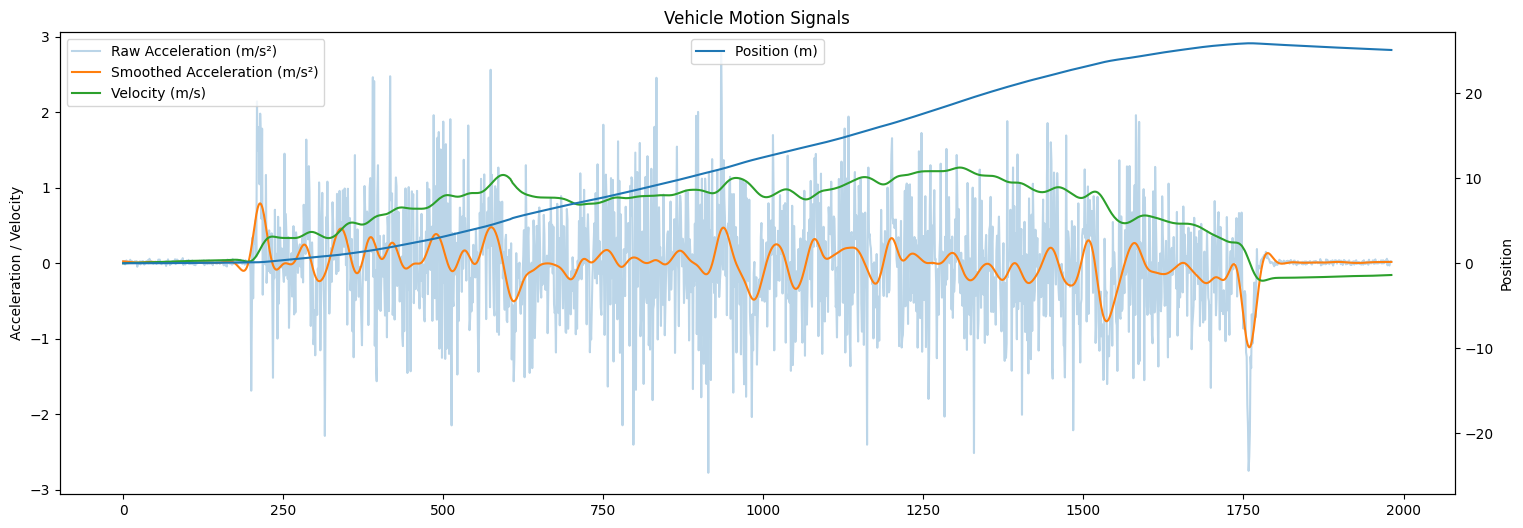

In [ ]:
# TOTAL LENGTH GROUND TRUTH: 24m

# First 205 samples are stationary → average = sensor bias, removed before integration
accel_mean = np.mean(accel_x[:205])
accel_x   -= accel_mean

# Empirical scale factor: tuned until the integrated position matches the known 24 m ground truth
accel_gain = 0.6
accel_x   *= accel_gain

# Low-pass filter to reduce noise, then integrate acceleration → velocity → position
accel_smoothed = butterworth_filter(accel_x, cutoff=0.05)
velocity       = cumulative_trapezoid(accel_smoothed, timestamps_s, initial=0.0)
position       = cumulative_trapezoid(velocity,       timestamps_s, initial=0.0)

plot_motion_signals(
    accel_raw=accel_x,
    accel_smoothed=accel_smoothed,
    velocity=velocity,
    position=position,
)

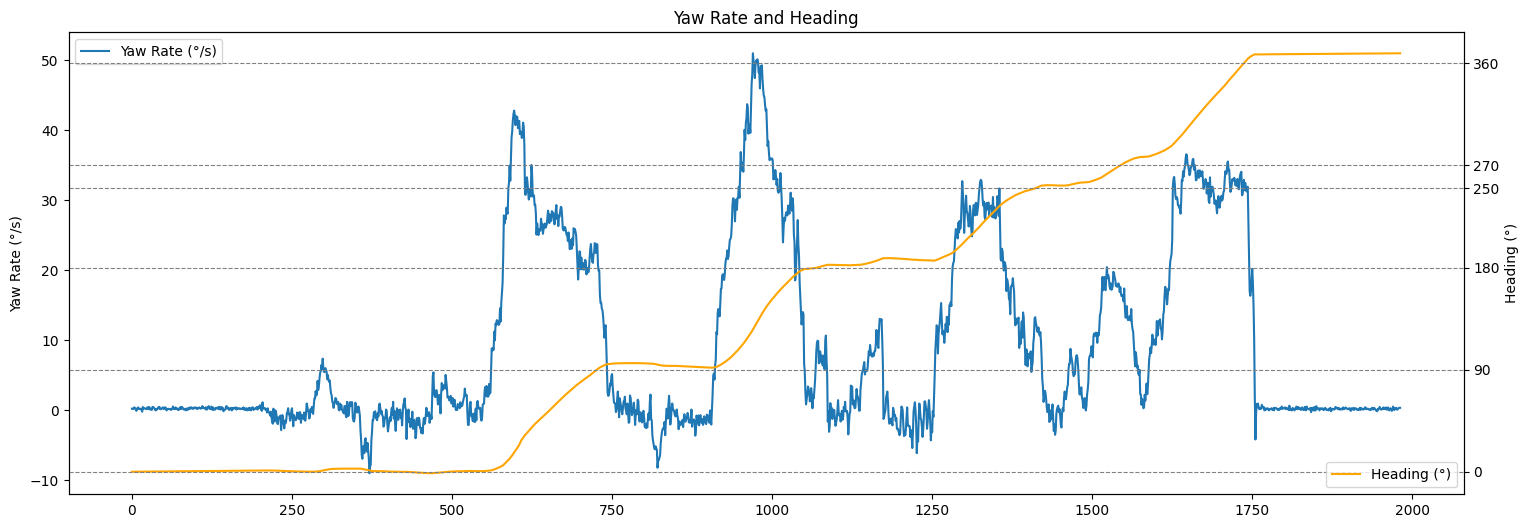

In [ ]:
# Integrate yaw rate over time to get heading angle (degrees turned since start)
heading = cumulative_trapezoid(yaw_rate, timestamps_s, initial = 0)

plot_yaw_and_heading(
    yaw_rate=yaw_rate,
    timestamps_s=timestamps_s,
    hlines = [0, 90, 180, 250, 270, 360] # reference angles to identify turn phases
)

## Ackermann Commands

In [ ]:
# Extract speed, steering angle, and timestamps from the Ackermann drive commands


# Convert timestamps from nanoseconds to seconds, starting at t=0


# Time delta between each sample — used for step-wise integration


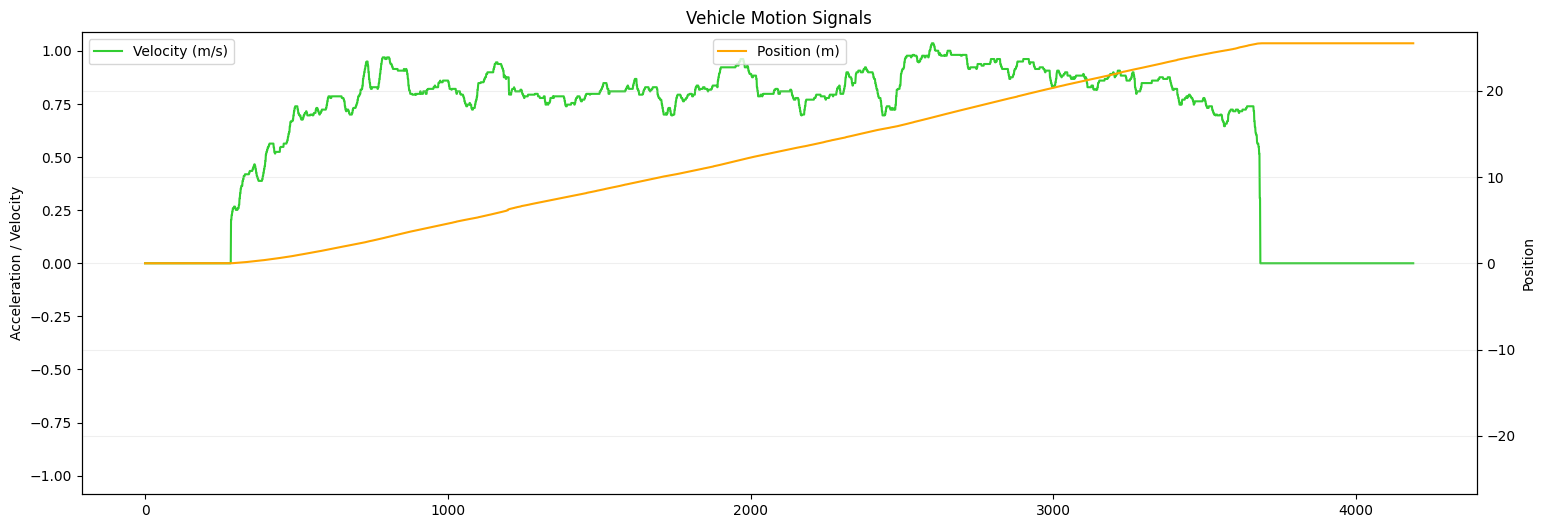

In [ ]:
# Physical wheelbase of the MXcarkit platform


# Integrate speed over time to get distance travelled


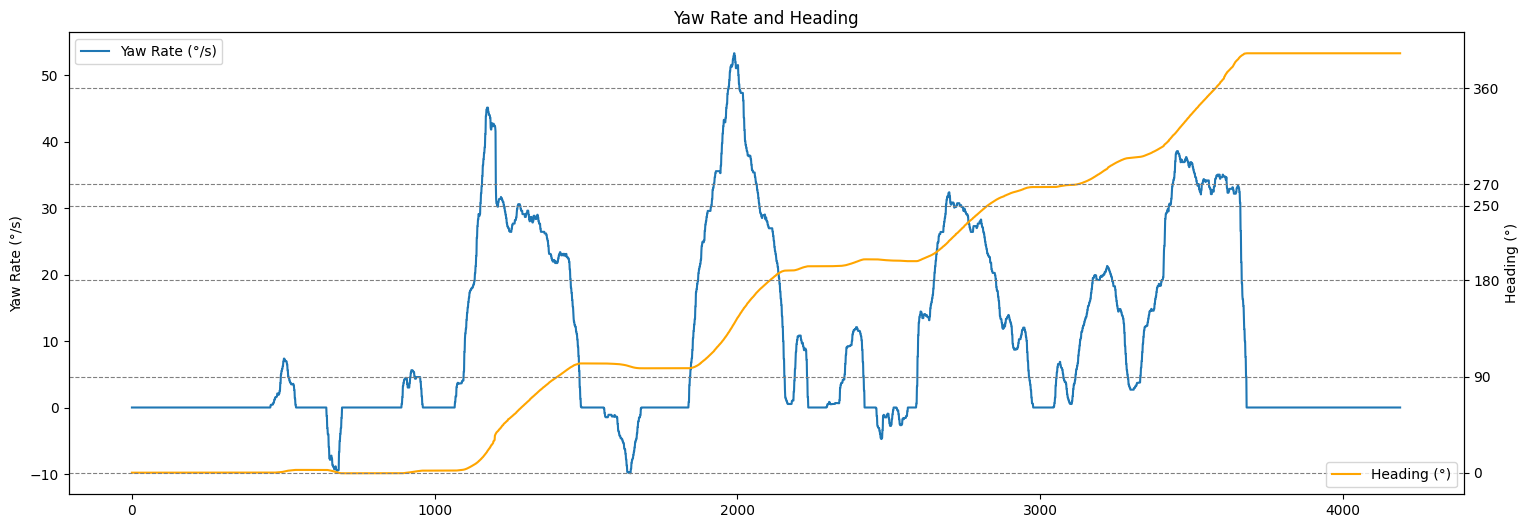

In [ ]:
# Ackermann kinematic model: yaw rate derived from speed, steering angle, and wheelbase
yaw_rate = velocity * np.tan(steering_angle) / wheelbase  # rad/s
heading  = cumulative_trapezoid(yaw_rate, timestamps_s, initial=0)  # heading angle in rad since start

plot_yaw_and_heading(
    yaw_rate=yaw_rate,
    heading=heading,
    timestamps_s=timestamps_s,
    hlines=[0, 90, 180, 250, 270, 360]  # reference angles to identify turn phases
)

## Vehicle Odometry Path

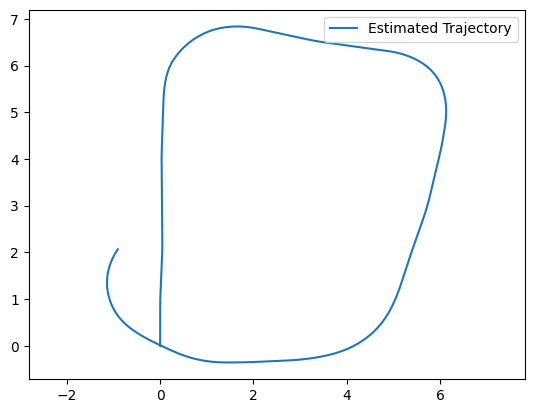

In [ ]:
# Convert the forward vehicle velocity into global x/y movement
# using the estimated heading direction

x = np.cumsum(velocity * np.cos(heading) * dt)
y = np.cumsum(velocity * np.sin(heading) * dt)

# Plot the estimated 2D driving trajectory
plt.plot(y, x, label='Estimated Trajectory')

# Keep equal scaling on both axes so the trajectory is not distorted
plt.axis('equal')

plt.legend()
plt.show()

## DXF Ground Truth

In [ ]:
!pip -qq install ezdxf >/dev/null 2>&1

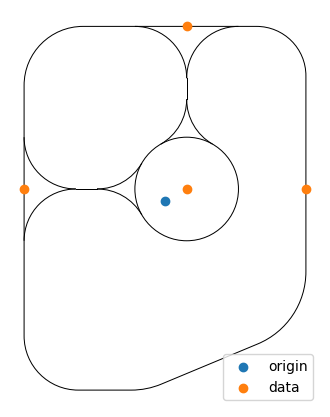

In [ ]:
import matplotlib.pyplot as plt
import ezdxf
from ezdxf import recover
from ezdxf.addons.drawing import RenderContext, Frontend
from ezdxf.addons.drawing.matplotlib import MatplotlibBackend
from ezdxf.addons.drawing.config import Configuration, BackgroundPolicy


# ── Color policy ──────────────────────────────────────────────────────────────

def black_color_policy(rgb: tuple) -> tuple:
    """Force every DXF entity to render in black, regardless of its layer color."""
    return (0, 0, 0)


# ── 1. Load DXF file ──────────────────────────────────────────────────────────

try:
    doc, auditor = recover.readfile('/content/cp_path_dxf.dxf')
except IOError:
    raise FileNotFoundError("Could not find or read the DXF file.")


# ── 2. Configure renderer ─────────────────────────────────────────────────────

config = Configuration(
    background_policy=BackgroundPolicy.OFF,  # Transparent background
    color_policy=black_color_policy,         # All entities drawn in black
)

ctx = RenderContext(doc)


# ── 3. Set up Matplotlib figure ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_alpha(0)      # Transparent figure background
ax.set_facecolor("none")    # Transparent axes background


# ── 4. Render DXF model space ─────────────────────────────────────────────────

out = MatplotlibBackend(ax)
Frontend(ctx, out, config=config).draw_layout(doc.modelspace(), finalize=True)


# ── 5. Overlay your own data points ──────────────────────────────────────────
# Coordinates are (x, y) in mm — Z is not used in 2D plots.
# Format: ax.scatter([x1, x2, ...], [y1, y2, ...])

x_coords = [450, 2925, 450, -2925]
y_coords = [250, 250, 3625, 250]

ax.scatter(0, 0, label='origin', zorder=5)
ax.scatter(x_coords, y_coords, label='data', zorder=5)

# ── 6. Finalize plot ──────────────────────────────────────────────────────────

ax.set_aspect('equal')  # Preserve true geometry (no distortion)
ax.set_xlabel("mm")
ax.set_ylabel("mm")
plt.legend()
plt.show()